In [1]:
import os, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("EIA_API_KEY")
BASE_URL = "https://api.eia.gov/v2/electricity/retail-sales/data/"

def get_eia(state="VA", sector="COM", metric="sales", start="2010", end="2024"):
    params = {
        "api_key": API_KEY,
        "frequency": "annual",
        "data[]": metric,
        "facets[stateid][]": state,
        "facets[sectorid][]": sector,
        "start": start,
        "end": end,
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000
    }
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()
    df = pd.DataFrame(r.json()["response"]["data"])
    df["period"] = pd.to_numeric(df["period"])
    df[metric] = pd.to_numeric(df[metric])
    return df

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)

In [3]:
states = ["VA", "MD", "NC", "PA", "US"]
sectors = ["RES", "COM", "IND", "ALL"]
metrics = ["sales", "price", "revenue", "customers"]

frames = []

for_state = []
for state in states:
    for sector in sectors:
        metric_frames = []
        for metric in metrics:
            temp = get_eia(state, sector, metric)
            temp = temp[["period", "stateid", "stateDescription", "sectorid", "sectorName", metric]]
            metric_frames.append(temp)

        merged = metric_frames[0]
        for mdf in metric_frames[1:]:
            merged = merged.merge(
                mdf,
                on=["period", "stateid", "stateDescription", "sectorid", "sectorName"],
                how="outer"
            )
        frames.append(merged)

retail = pd.concat(frames, ignore_index=True)
retail.head()

,period,stateid,stateDescription,sectorid,sectorName,sales,price,revenue,customers
0,2010,VA,Virginia,RES,residential,48438.95800,10.45,5061.60340,NaN
1,2011,VA,Virginia,RES,residential,45771.14400,10.64,4871.34880,NaN
2,2012,VA,Virginia,RES,residential,43534.67500,11.08,4822.89280,NaN
3,2013,VA,Virginia,RES,residential,45416.25301,10.84,4924.51001,NaN
4,2014,VA,Virginia,RES,residential,46443.71600,11.10,5155.28080,NaN


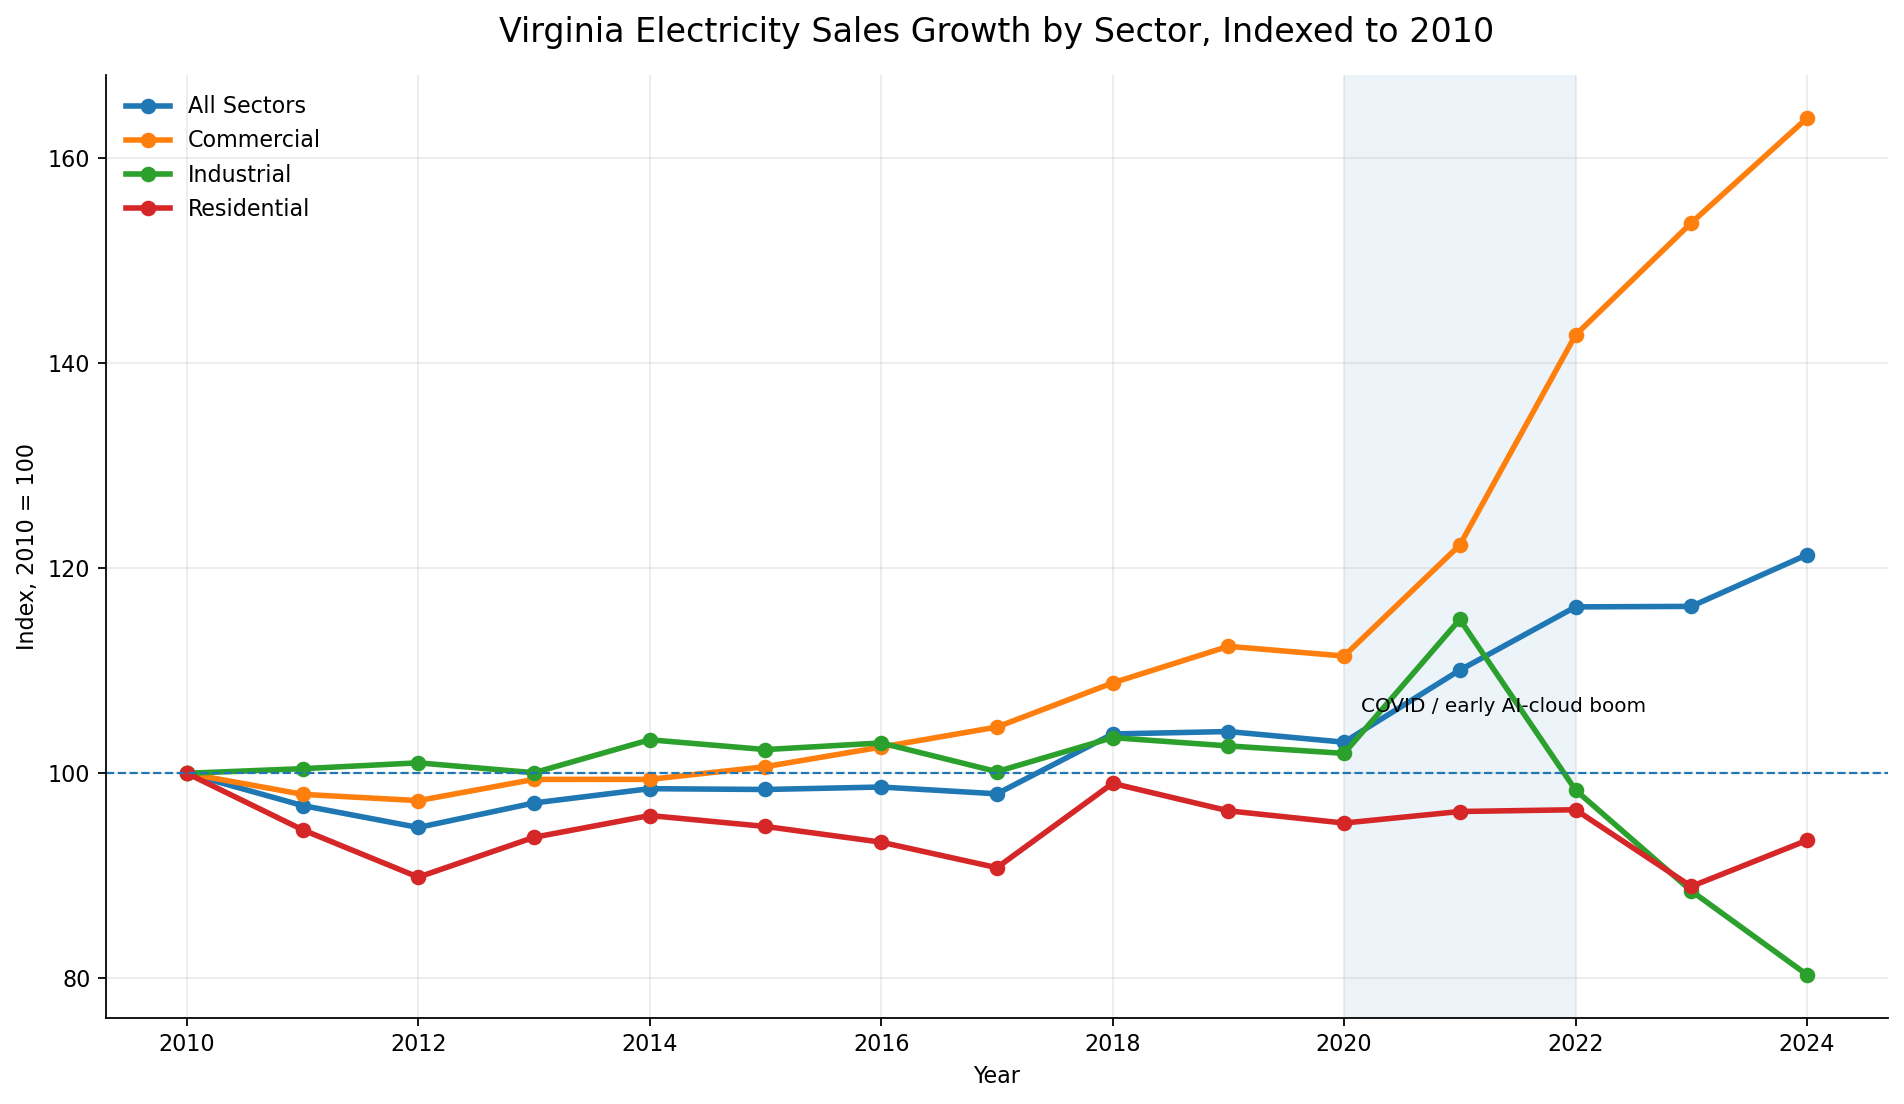

In [4]:
va = retail[retail["stateid"] == "VA"].copy()

fig, ax = plt.subplots(figsize=(12, 7), dpi=160)

for sector, group in va.groupby("sectorName"):
    group = group.sort_values("period")
    group["sales_index"] = group["sales"] / group["sales"].iloc[0] * 100
    ax.plot(group["period"], group["sales_index"], marker="o", linewidth=2.5, label=sector.title())

ax.axhline(100, linestyle="--", linewidth=1)
ax.axvspan(2020, 2022, alpha=0.08)
ax.text(2020.15, 106, "COVID / early AI-cloud boom", fontsize=9)

ax.set_title("Virginia Electricity Sales Growth by Sector, Indexed to 2010", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

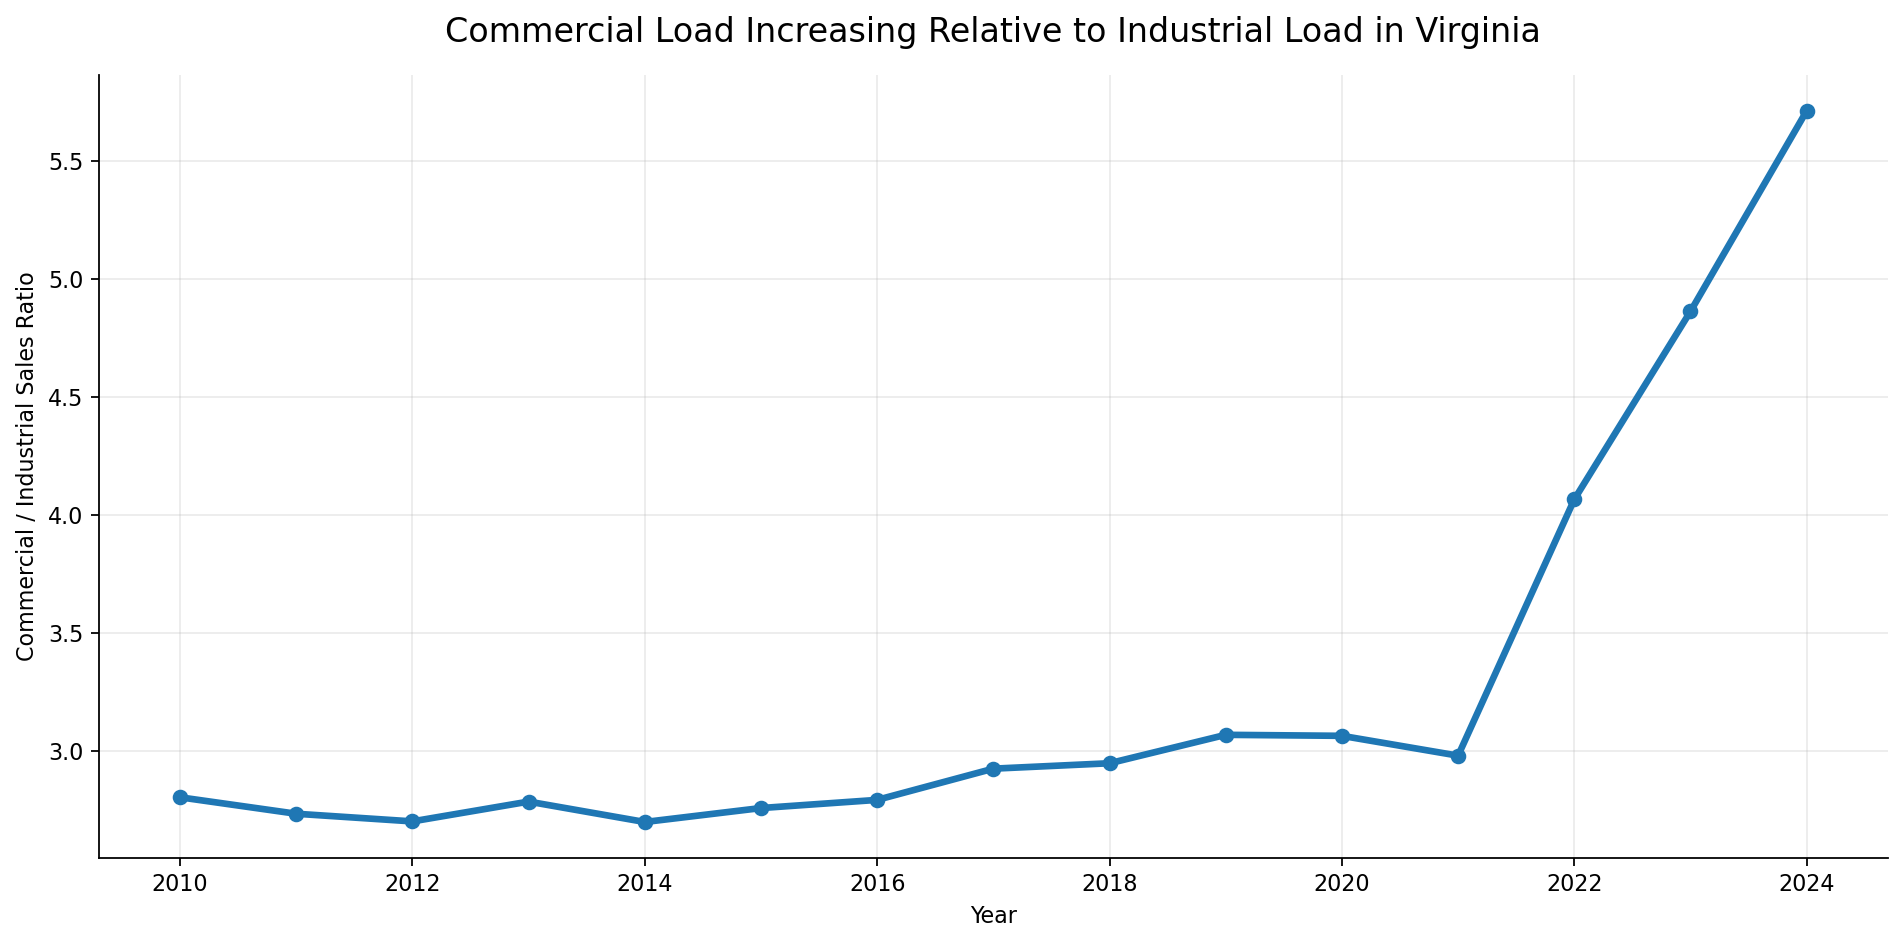

In [5]:
wide = va.pivot_table(
    index="period",
    columns="sectorid",
    values="sales",
    aggfunc="first"
).reset_index()

wide["commercial_minus_industrial"] = wide["COM"] - wide["IND"]
wide["commercial_to_industrial_ratio"] = wide["COM"] / wide["IND"]

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

ax.plot(wide["period"], wide["commercial_to_industrial_ratio"], marker="o", linewidth=3)

ax.set_title("Commercial Load Increasing Relative to Industrial Load in Virginia", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Commercial / Industrial Sales Ratio")
clean_axes(ax)

plt.tight_layout()
plt.show()

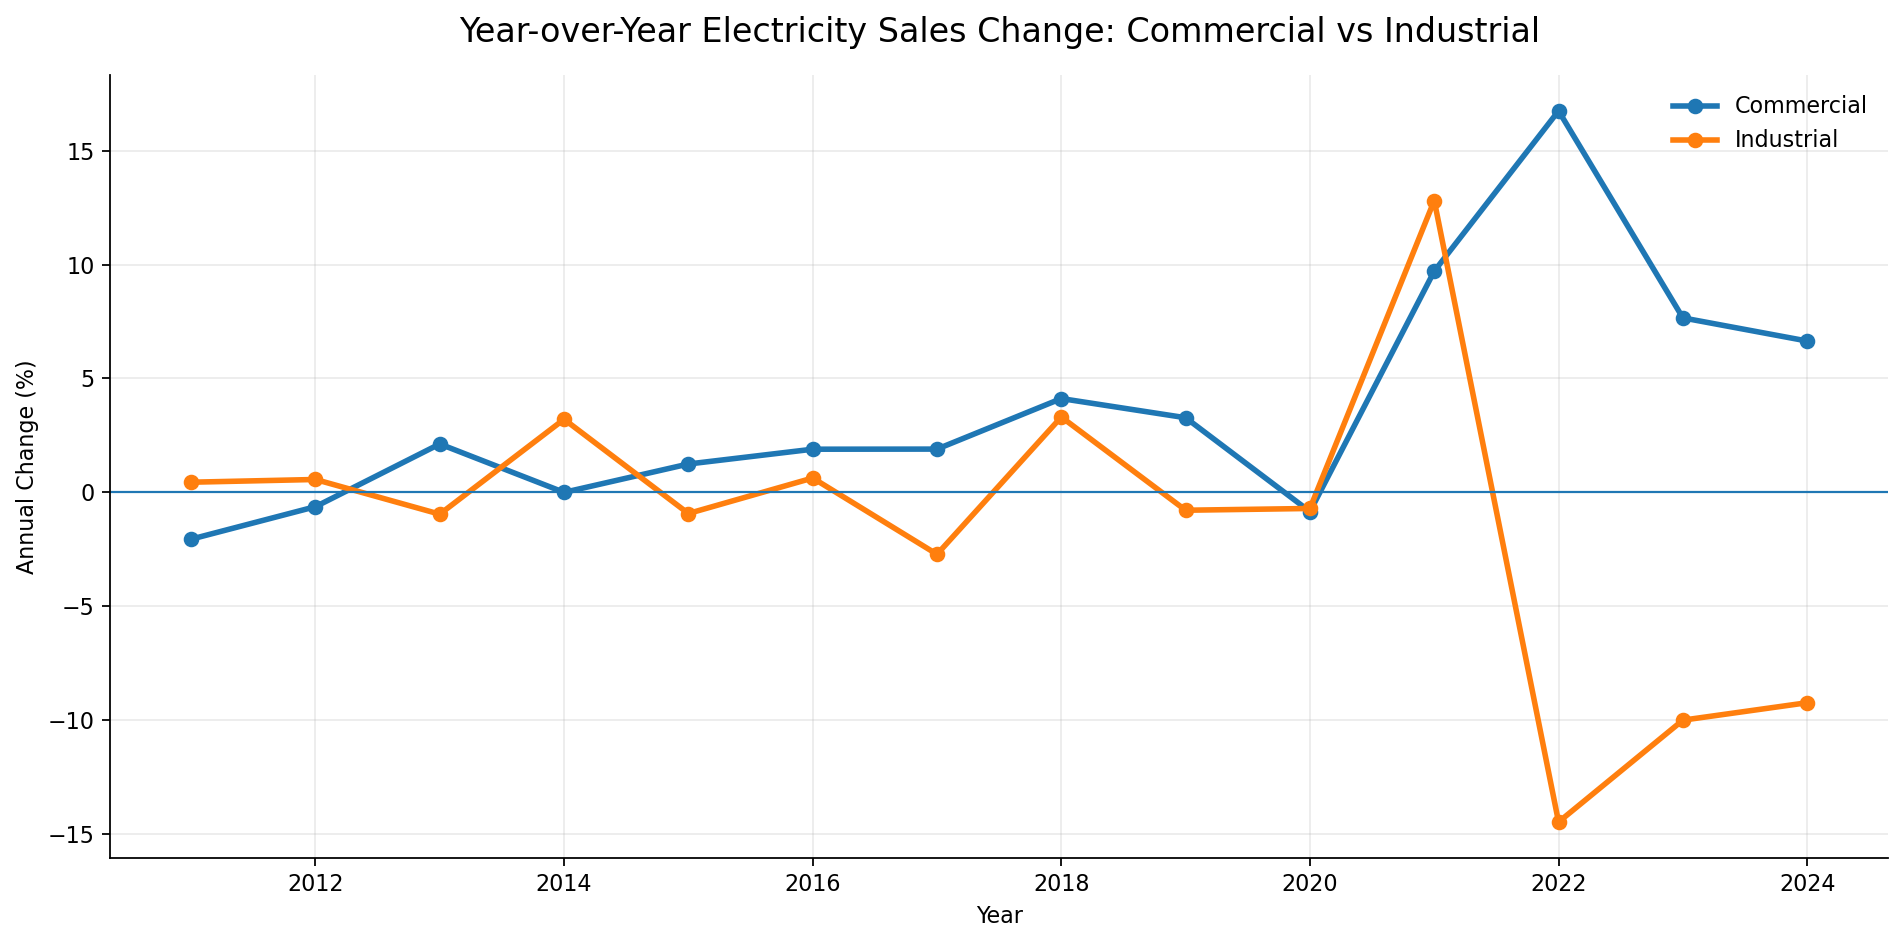

In [6]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

for sector in ["commercial", "industrial"]:
    group = va[va["sectorName"] == sector].sort_values("period").copy()
    group["yoy"] = group["sales"].pct_change() * 100
    ax.plot(group["period"], group["yoy"], marker="o", linewidth=2.5, label=sector.title())

ax.axhline(0, linewidth=1)
ax.set_title("Year-over-Year Electricity Sales Change: Commercial vs Industrial", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Change (%)")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

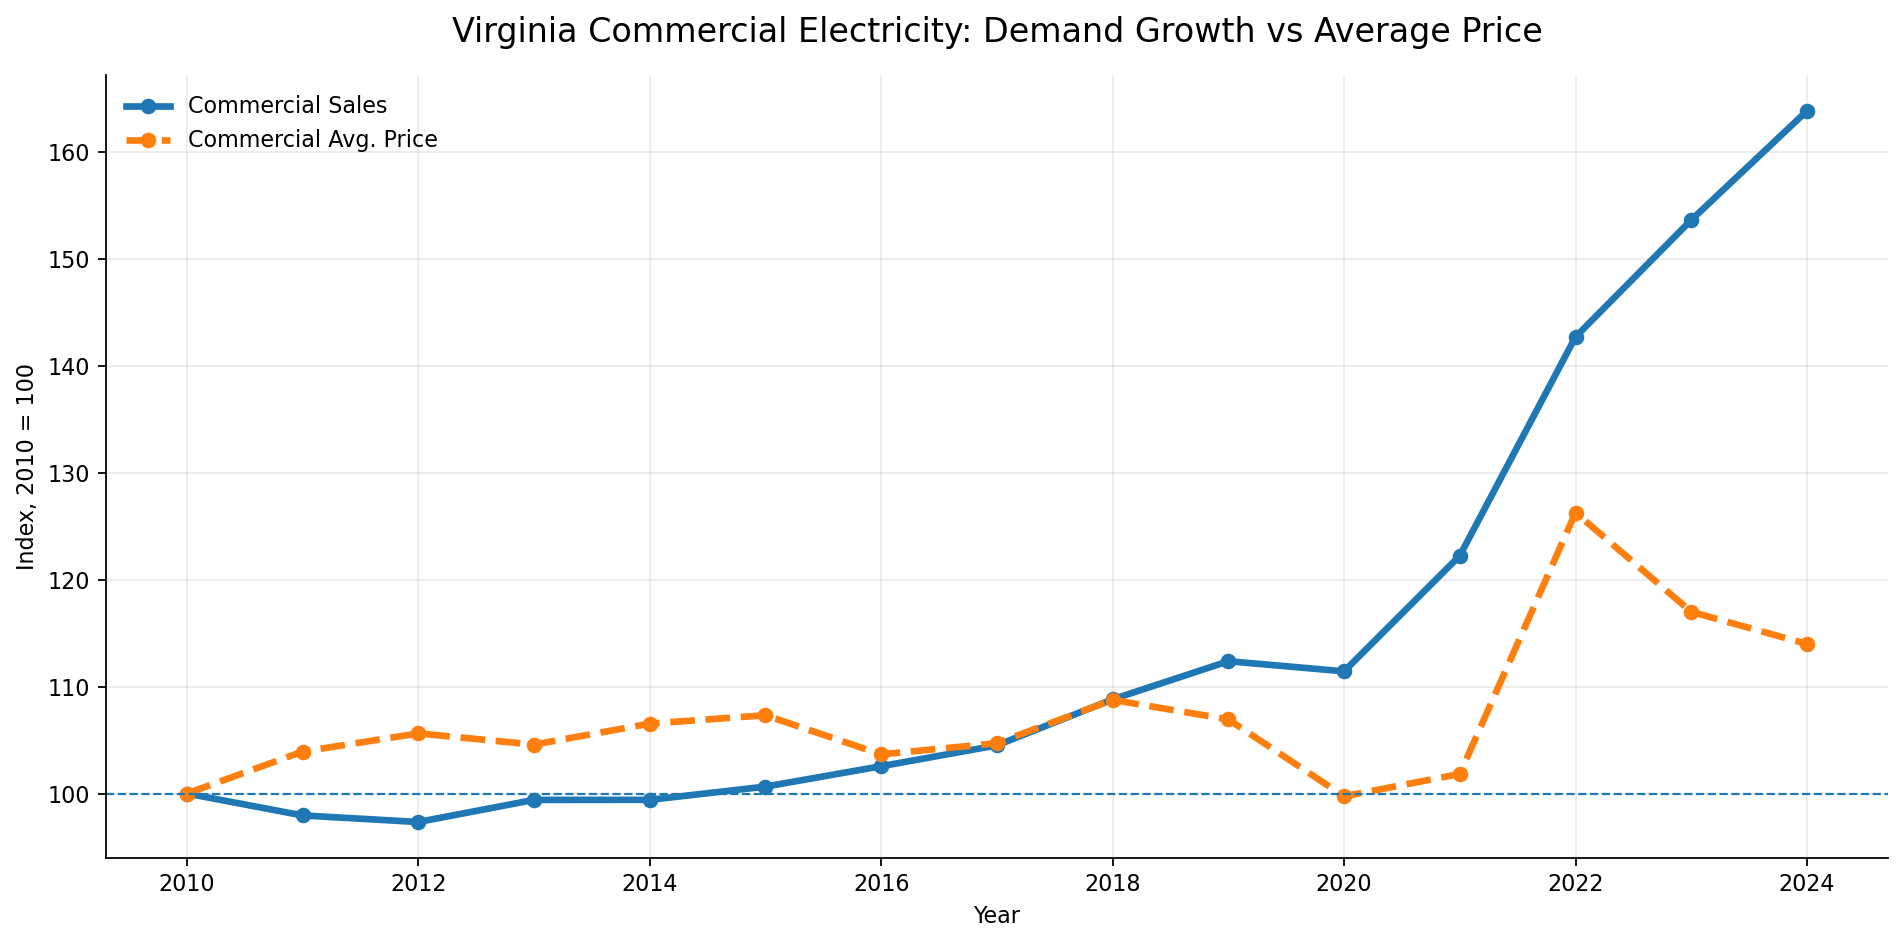

In [7]:
com = va[va["sectorid"] == "COM"].sort_values("period").copy()
com["sales_index"] = com["sales"] / com["sales"].iloc[0] * 100
com["price_index"] = com["price"] / com["price"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

ax.plot(com["period"], com["sales_index"], marker="o", linewidth=3, label="Commercial Sales")
ax.plot(com["period"], com["price_index"], marker="o", linewidth=3, linestyle="--", label="Commercial Avg. Price")

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Virginia Commercial Electricity: Demand Growth vs Average Price", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

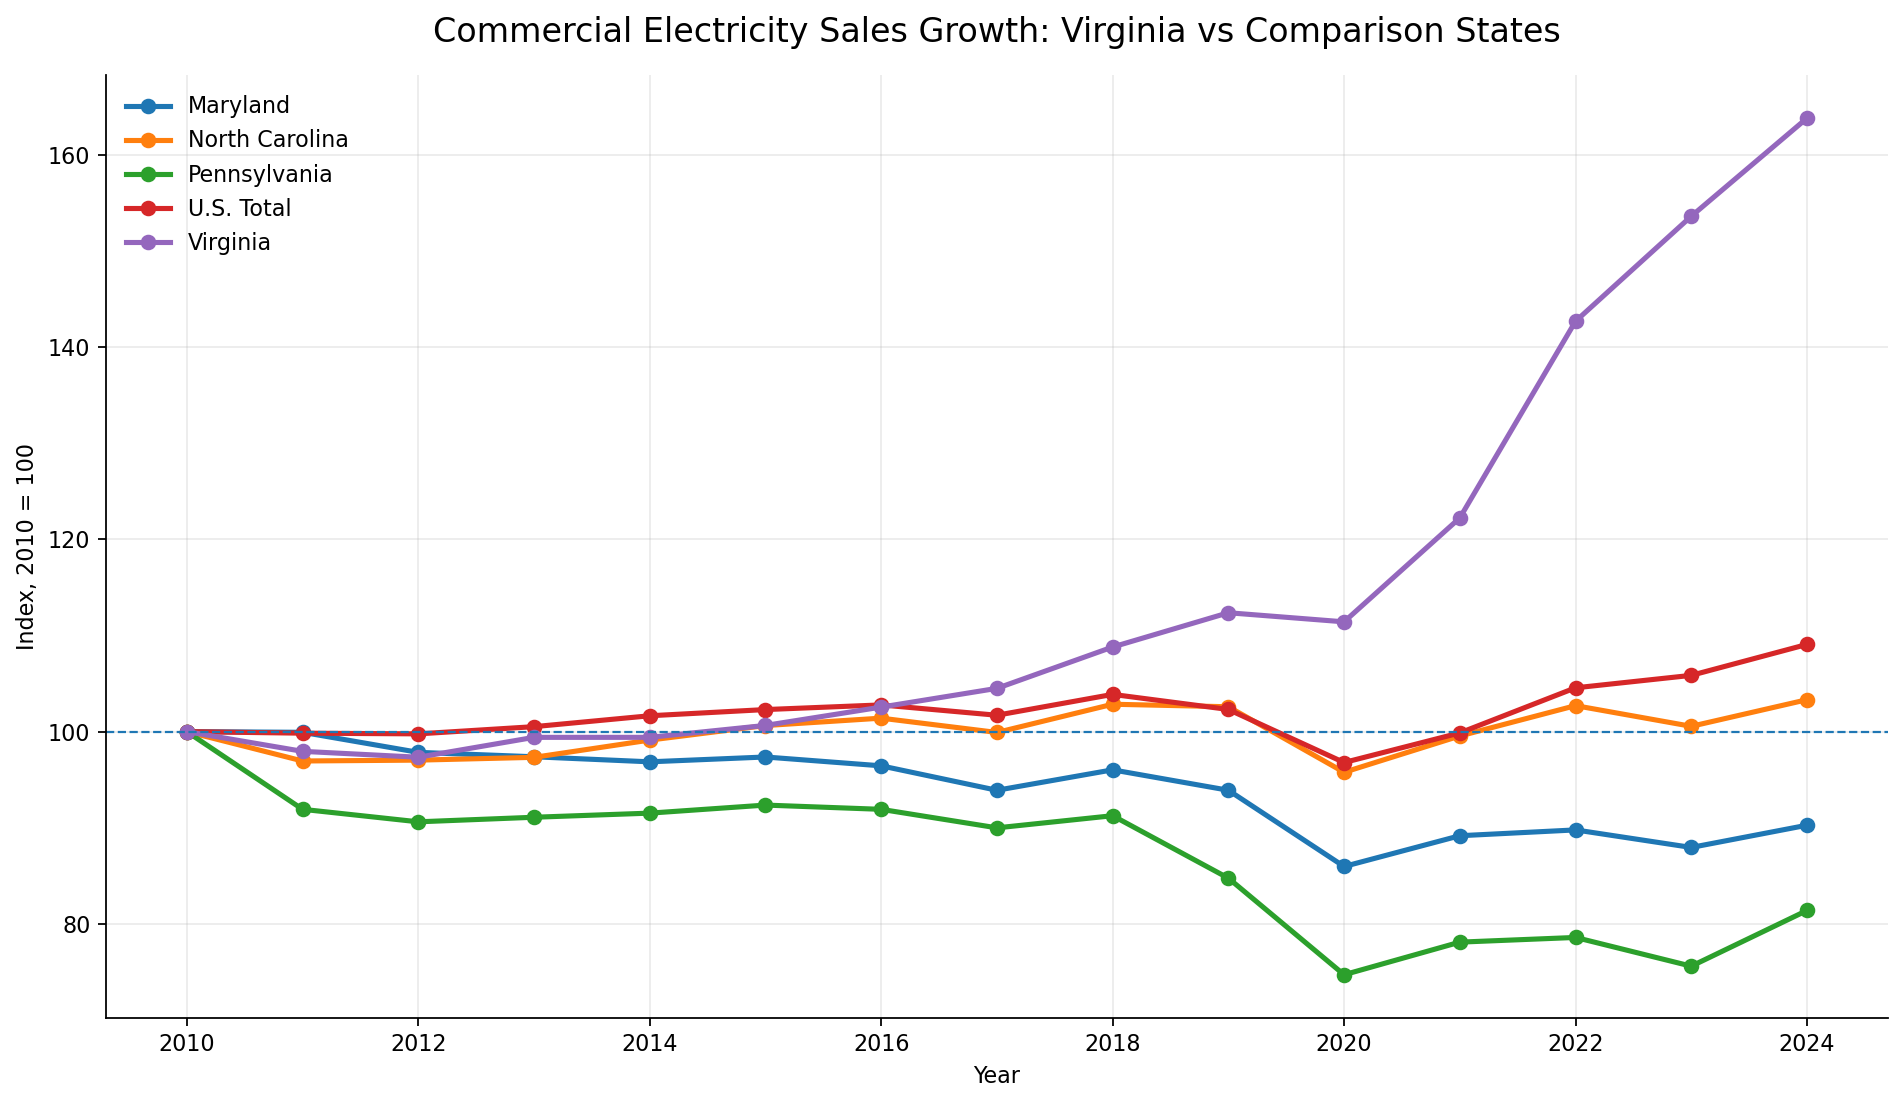

In [8]:
comp = retail[retail["sectorid"] == "COM"].copy()

fig, ax = plt.subplots(figsize=(12, 7), dpi=160)

for state, group in comp.groupby("stateDescription"):
    group = group.sort_values("period")
    group["sales_index"] = group["sales"] / group["sales"].iloc[0] * 100
    ax.plot(group["period"], group["sales_index"], marker="o", linewidth=2.3, label=state)

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Commercial Electricity Sales Growth: Virginia vs Comparison States", fontsize=15, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Index, 2010 = 100")
clean_axes(ax)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [9]:
summary = []

for sector in ["COM", "IND", "ALL"]:
    g = va[va["sectorid"] == sector].sort_values("period")
    start_sales = g["sales"].iloc[0]
    end_sales = g["sales"].iloc[-1]
    growth_pct = (end_sales / start_sales - 1) * 100

    summary.append({
        "Sector": g["sectorName"].iloc[0].title(),
        "2010 Sales": start_sales,
        "2024 Sales": end_sales,
        "Growth %": growth_pct,
        "2024 Price": g["price"].iloc[-1],
        "2024 Customers": g["customers"].iloc[-1]
    })

summary_df = pd.DataFrame(summary)
summary_df

,Sector,2010 Sales,2024 Sales,Growth %,2024 Price,2024 Customers
0,Commercial,48036.98399,78710.66201,63.854296,8.72,445756.0
1,Industrial,17141.22400,13775.53000,-19.635086,8.99,3794.0
2,All Sectors,113806.13500,138044.77200,21.298181,10.62,4104032.0


In [11]:
import statsmodels.api as sm

com = va[va["sectorid"]=="COM"].sort_values("period").copy()

com["time"] = range(len(com))
com["post2020"] = (com["period"] >= 2020).astype(int)
com["interaction"] = com["time"] * com["post2020"]

X = com[["time","post2020","interaction"]]
X = sm.add_constant(X)

model = sm.OLS(com["sales"],X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     290.4
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           9.45e-11
Time:                        21:21:32   Log-Likelihood:                -126.60
No. Observations:                  15   AIC:                             261.2
Df Residuals:                      11   BIC:                             264.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.608e+04    768.783     59.934      

In [12]:
comparison = retail[
(retail["stateid"].isin(["MD","NC","PA"])) &
(retail["sectorid"]=="COM")
]

counter = comparison.groupby("period")["sales"].mean().reset_index()

va_com = retail[
(retail["stateid"]=="VA") &
(retail["sectorid"]=="COM")
]

In [13]:
com["pct_sales"] = com["sales"].pct_change()
com["pct_price"] = com["price"].pct_change()

elasticity = (
com["pct_sales"] /
com["pct_price"]
).mean()

print(elasticity)


0.0651561277412134
